# Local Volatility (Dupire 1994)

Dupire (1994) showed that, given a complete implied-volatility surface $\sigma_{BS}(K, T)$, there exists a unique diffusion

$$dS_t = S_t \, \sigma_{\text{loc}}(S_t, t) \, dW_t$$

consistent with all European option prices. The local volatility function is given by

$$\sigma_{\text{loc}}^2(K, T) = \frac{\partial w / \partial T}{g(k, w)}$$

where $w(k, T) = \sigma_{BS}^2(k, T) \cdot T$ is the **total implied variance**, $k = \ln(K/F(T))$ is **log-moneyness**, and the **Gatheral-Jacquier density weight** is

$$g(k, w) = \left(1 - \frac{k \, w_k}{2w}\right)^2 - \frac{w_k^2}{4}\left(\frac{1}{4} + \frac{1}{w}\right) + \frac{w_{kk}}{2}$$

This notebook covers:
1. Dupire formula derivation and intuition
2. Flat IV surface -> flat local vol (sanity check)
3. SVI-calibrated local vol surface from a Heston model
4. Comparison: SVI-analytical route vs. numerical IV-grid route
5. Local vol surface visualizations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D

import foureng as fe

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.35})
print(f'foureng {fe.__version__}')

foureng 0.5.0


## 1. Dupire Formula: Intuition

The key insight is that the **denominator** $g(k,w)$ is proportional to the risk-neutral density $q(K,T)$ implied by the smile:

$$q(K,T) = e^{rT} \frac{\partial^2 C}{\partial K^2}$$

When $g < 0$ at some $(k, T)$, the IV surface implies a **negative risk-neutral density** -- a butterfly arbitrage. The SVI parameterization's $g(k) \geq 0$ condition (Gatheral-Jacquier 2014) prevents this.

The numerator $\partial w / \partial T$ is the rate of variance **accumulation** with time -- it must be non-negative for the surface to be free of calendar spread arbitrage.

Together, $\sigma_{\text{loc}}^2 = (\partial w/\partial T) / g \geq 0$ whenever the surface is arbitrage-free.

## 2. Flat IV Surface -> Flat Local Vol

For a flat smile $\sigma_{BS}(k,T) = \sigma_0$ (constant), we have:
- $w(k,T) = \sigma_0^2 T$
- $\partial w/\partial T = \sigma_0^2$
- $w_k = 0$, $w_{kk} = 0$, so $g(k,w) = 1$

Therefore $\sigma_{\text{loc}} = \sigma_0$ everywhere. Let's verify.

In [2]:
SIGMA_FLAT = 0.25
K_GRID     = np.linspace(-1.0, 1.0, 51)
MATURITIES = np.array([0.25, 0.5, 1.0, 2.0])

def flat_svi(T, sigma=SIGMA_FLAT):
    """SVI params that produce a perfectly flat smile at vol=sigma."""
    a = sigma**2 * T
    return fe.SVIParams(a=a, b=1e-8, rho=0.0, m=0.0, sigma=0.3)

flat_params = [flat_svi(T) for T in MATURITIES]
lv_flat = fe.dupire_local_vol_from_svi(K_GRID, MATURITIES, flat_params)

print(f'Local vol surface shape: {lv_flat.local_vol.shape}  (nT_mid={len(lv_flat.maturities)}, nK={len(lv_flat.log_moneyness)})')
print(f'Midpoint maturities: {lv_flat.maturities}')

# Interior k only (edge effects from b -> 0)
k_int = np.abs(K_GRID) < 0.8
lv_int = lv_flat.local_vol[:, k_int]
print(f'\nExpected sigma_loc = {SIGMA_FLAT:.4f}')
print(f'Observed min  = {lv_int.min():.6f}')
print(f'Observed max  = {lv_int.max():.6f}')
print(f'Max abs error = {np.abs(lv_int - SIGMA_FLAT).max():.2e}')

Local vol surface shape: (3, 51)  (nT_mid=3, nK=51)
Midpoint maturities: [0.375 0.75  1.5  ]

Expected sigma_loc = 0.2500
Observed min  = 0.250000
Observed max  = 0.250000
Max abs error = 3.76e-08


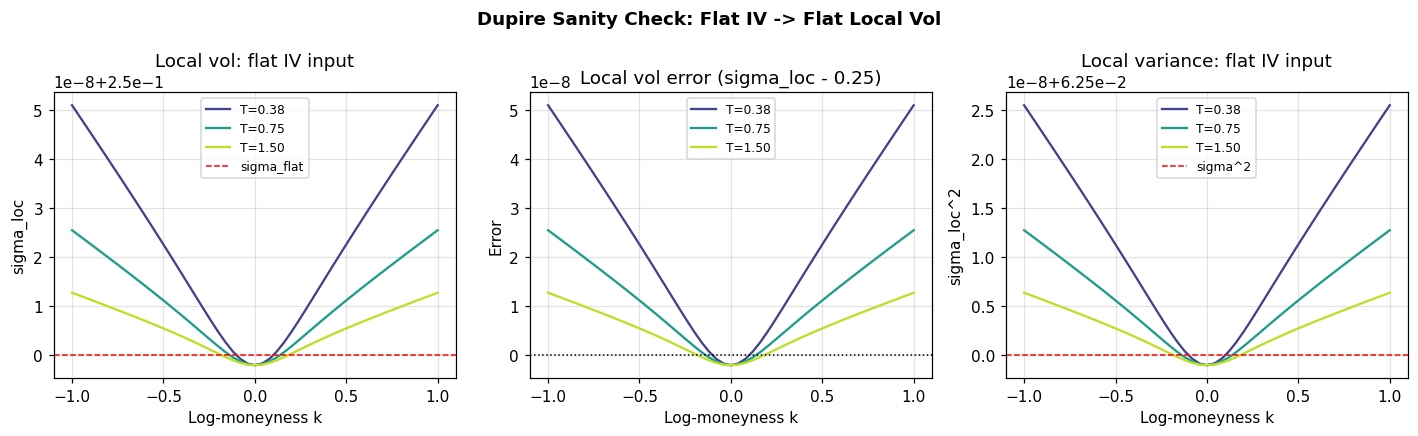

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(lv_flat.maturities)))

for i, (T_mid, c) in enumerate(zip(lv_flat.maturities, colors)):
    axes[0].plot(K_GRID, lv_flat.local_vol[i], color=c, label=f'T={T_mid:.2f}')
axes[0].axhline(SIGMA_FLAT, color='red', ls='--', lw=1, label='sigma_flat')
axes[0].set(title='Local vol: flat IV input', xlabel='Log-moneyness k', ylabel='sigma_loc')
axes[0].legend(fontsize=8)

# Error
for i, (T_mid, c) in enumerate(zip(lv_flat.maturities, colors)):
    axes[1].plot(K_GRID, lv_flat.local_vol[i] - SIGMA_FLAT, color=c, label=f'T={T_mid:.2f}')
axes[1].axhline(0, color='black', ls=':', lw=1)
axes[1].set(title='Local vol error (sigma_loc - 0.25)', xlabel='Log-moneyness k', ylabel='Error')
axes[1].legend(fontsize=8)

# Local variance
for i, (T_mid, c) in enumerate(zip(lv_flat.maturities, colors)):
    axes[2].plot(K_GRID, lv_flat.local_var[i], color=c, label=f'T={T_mid:.2f}')
axes[2].axhline(SIGMA_FLAT**2, color='red', ls='--', lw=1, label='sigma^2')
axes[2].set(title='Local variance: flat IV input', xlabel='Log-moneyness k', ylabel='sigma_loc^2')
axes[2].legend(fontsize=8)

fig.suptitle('Dupire Sanity Check: Flat IV -> Flat Local Vol', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. SVI-Calibrated Local Vol from a Heston Model

We price options under the Heston stochastic volatility model, extract the implied vol surface, calibrate SVI smiles at each maturity, and then apply the Dupire formula analytically via `dupire_local_vol_from_svi`.

In [4]:
# Heston model setup
S0  = 100.0
r   = 0.03
q   = 0.01
F0  = S0 * np.exp((r - q) * 1.0)   # 1-year forward for reference

heston = fe.HestonParams(kappa=2.0, theta=0.04, nu=0.5, rho=-0.7, v0=0.04)
MATS   = np.array([0.25, 0.5, 1.0, 1.5, 2.0])
k_arr  = np.linspace(-0.8, 0.5, 41)

print('Heston params:', heston)
print(f'Maturities: {MATS}')
print(f'Log-moneyness range: [{k_arr[0]:.2f}, {k_arr[-1]:.2f}], nK={len(k_arr)}')

Heston params: HestonParams(name='heston', kappa=2.0, theta=0.04, nu=0.5, rho=-0.7, v0=0.04)
Maturities: [0.25 0.5  1.   1.5  2.  ]
Log-moneyness range: [-0.80, 0.50], nK=41


In [5]:
# Build IV grid from Heston via COS pricer
def heston_iv_smile(T, k_grid, S0=S0, r=r, q=q, params=heston):
    F = S0 * np.exp((r - q) * T)
    strikes = F * np.exp(k_grid)
    fwd = fe.ForwardSpec(S0=S0, r=r, q=q, T=T)
    cf  = lambda u: fe.heston_cf_form2(u, fwd, params)
    grid = fe.cos_auto_grid(fe.heston_cumulants(fwd, params), N=256, L=12.0)
    res  = fe.cos_prices(cf, fwd, strikes.tolist(), grid)
    call_px = res.call_prices
    ivs = []
    for K, c in zip(strikes, call_px):
        try:
            iv = fe.implied_vol_newton_safeguarded(
                float(c), fe.BSInputs(float(F), float(K), float(T), float(r), float(q), True)
            )
        except Exception:
            iv = np.nan
        ivs.append(iv)
    return np.array(ivs)

iv_grid = np.array([heston_iv_smile(T, k_arr) for T in MATS])
print(f'IV grid shape: {iv_grid.shape}')
print(f'ATM IVs: {[f"{iv_grid[i, len(k_arr)//2]:.3f}" for i in range(len(MATS))]}')

IV grid shape: (5, 41)
ATM IVs: ['0.242', '0.230', '0.215', '0.207', '0.203']


In [6]:
# Calibrate SVI smiles at each maturity
svi_params = []
svi_fits   = []
for i, T in enumerate(MATS):
    iv_row = iv_grid[i]
    mask = np.isfinite(iv_row) & (iv_row > 0.005)
    result = fe.fit_svi_smile(k_arr[mask], iv_row[mask], T, use_global=False)
    svi_params.append(result.params)
    svi_fits.append(result)
    print(f'T={T:.2f}: RMSE={result.rmse*100:.3f}bp  MaxErr={result.max_err*100:.3f}bp  BF-free={result.butterfly_free}  params={result.params}')

T=0.25: RMSE=0.166bp  MaxErr=0.349bp  BF-free=True  params=SVIParams(a=np.float64(0.004706114039270056), b=np.float64(0.021068915549274373), rho=np.float64(-0.6676176366026743), m=np.float64(0.12410447332388737), sigma=np.float64(0.038756196711673185))
T=0.50: RMSE=0.103bp  MaxErr=0.206bp  BF-free=True  params=SVIParams(a=np.float64(0.008277184376046236), b=np.float64(0.03696972271793849), rho=np.float64(-0.6768925357296728), m=np.float64(0.13444941625568363), sigma=np.float64(0.06746455202510046))
T=1.00: RMSE=0.029bp  MaxErr=0.066bp  BF-free=True  params=SVIParams(a=np.float64(0.012768218690615483), b=np.float64(0.059028760548440196), rho=np.float64(-0.6649805134670208), m=np.float64(0.16991403392249413), sigma=np.float64(0.14796623118269042))
T=1.50: RMSE=0.005bp  MaxErr=0.014bp  BF-free=True  params=SVIParams(a=np.float64(0.0149323238308832), b=np.float64(0.07369770618204957), rho=np.float64(-0.6326508228395783), m=np.float64(0.22012479372417268), sigma=np.float64(0.233971397829846

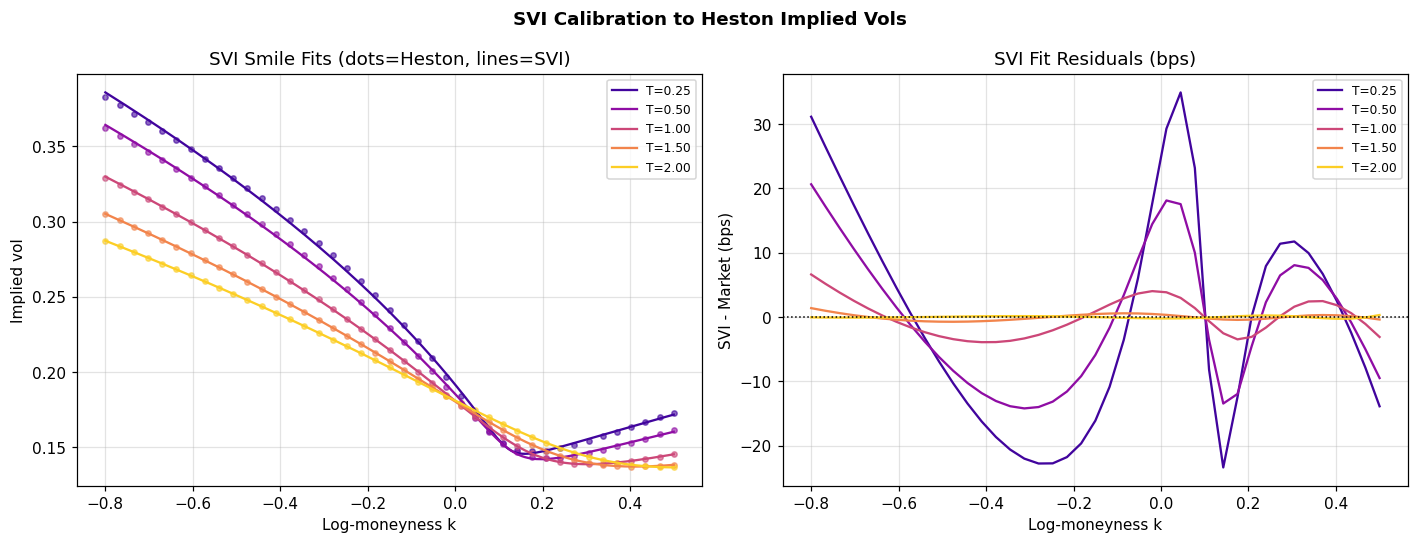

In [7]:
# Visualize SVI fits
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(MATS)))

for i, (T, c) in enumerate(zip(MATS, colors)):
    # Market IV (Heston)
    mask = np.isfinite(iv_grid[i]) & (iv_grid[i] > 0.005)
    axes[0].scatter(k_arr[mask], iv_grid[i][mask], s=12, color=c, alpha=0.6)
    # SVI fit
    k_fine = np.linspace(k_arr[0], k_arr[-1], 200)
    iv_fit = fe.svi_implied_vol(k_fine, T, svi_params[i])
    axes[0].plot(k_fine, iv_fit, color=c, label=f'T={T:.2f}')

axes[0].set(title='SVI Smile Fits (dots=Heston, lines=SVI)', 
            xlabel='Log-moneyness k', ylabel='Implied vol')
axes[0].legend(fontsize=8)

# Residuals
for i, (T, c) in enumerate(zip(MATS, colors)):
    mask = np.isfinite(iv_grid[i]) & (iv_grid[i] > 0.005)
    iv_fit_at_grid = fe.svi_implied_vol(k_arr[mask], T, svi_params[i])
    axes[1].plot(k_arr[mask], (iv_fit_at_grid - iv_grid[i][mask]) * 1e4, 
                 color=c, label=f'T={T:.2f}')
axes[1].axhline(0, color='black', ls=':', lw=1)
axes[1].set(title='SVI Fit Residuals (bps)', xlabel='Log-moneyness k', ylabel='SVI - Market (bps)')
axes[1].legend(fontsize=8)

fig.suptitle('SVI Calibration to Heston Implied Vols', fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Compute Dupire local vol surface (analytical SVI route)
lv_svi = fe.dupire_local_vol_from_svi(k_arr, MATS, svi_params)

print(f'Local vol surface shape: {lv_svi.local_vol.shape}')
print(f'Midpoint maturities: {lv_svi.maturities}')
print(f'Min local vol: {lv_svi.local_vol.min():.4f}')
print(f'Max local vol: {lv_svi.local_vol.max():.4f}')
print(f'All non-negative: {np.all(lv_svi.local_var >= 0)}')
print(f'All finite:       {np.all(np.isfinite(lv_svi.local_vol))}')

Local vol surface shape: (4, 41)
Midpoint maturities: [0.375 0.75  1.25  1.75 ]
Min local vol: 0.1193
Max local vol: 0.5541
All non-negative: True
All finite:       True


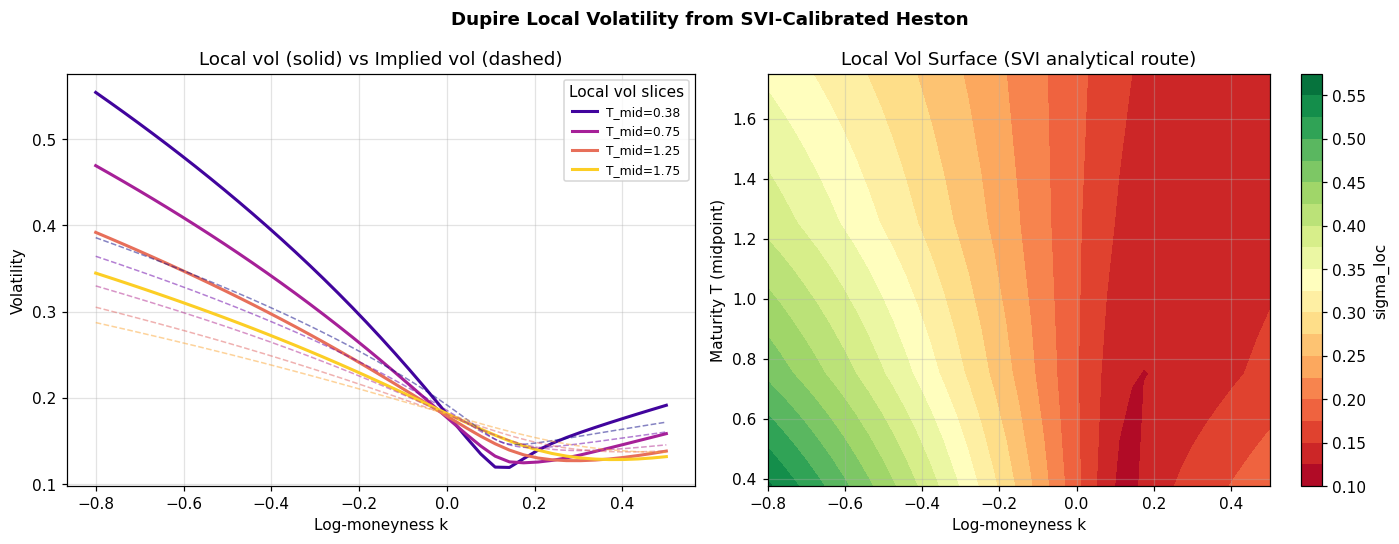

In [9]:
# Local vol slices vs implied vol
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(lv_svi.maturities)))

for i, (T_mid, c) in enumerate(zip(lv_svi.maturities, colors)):
    # Local vol
    axes[0].plot(k_arr, lv_svi.local_vol[i], color=c, lw=2, label=f'T_mid={T_mid:.2f}')

# Overlay implied vol slices at original maturities
for i, T in enumerate(MATS):
    k_fine = np.linspace(k_arr[0], k_arr[-1], 200)
    iv_svi = fe.svi_implied_vol(k_fine, T, svi_params[i])
    axes[0].plot(k_fine, iv_svi, ls='--', lw=1, alpha=0.5,
                 color=plt.cm.plasma(i / len(MATS)))

axes[0].set(title='Local vol (solid) vs Implied vol (dashed)',
            xlabel='Log-moneyness k', ylabel='Volatility')
axes[0].legend(fontsize=8, title='Local vol slices')

# Local variance surface
K_MG, T_MG = np.meshgrid(k_arr, lv_svi.maturities)
cs = axes[1].contourf(K_MG, T_MG, lv_svi.local_vol, levels=20, cmap='RdYlGn')
plt.colorbar(cs, ax=axes[1], label='sigma_loc')
axes[1].set(title='Local Vol Surface (SVI analytical route)',
            xlabel='Log-moneyness k', ylabel='Maturity T (midpoint)')

fig.suptitle('Dupire Local Volatility from SVI-Calibrated Heston', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Comparison: SVI-Analytical vs. Numerical IV-Grid Route

`dupire_local_vol_grid` uses finite differences directly on the IV surface -- faster to set up but more sensitive to numerical noise. Here we compare both routes on the same Heston surface.

In [10]:
# Numerical route: pass the raw IV grid
# Replace NaN with interpolated values for finite-diff stability
iv_clean = iv_grid.copy()
for i in range(len(MATS)):
    row = iv_clean[i]
    if np.any(np.isnan(row)):
        finite = np.isfinite(row)
        row[~finite] = np.interp(k_arr[~finite], k_arr[finite], row[finite])

lv_grid = fe.dupire_local_vol_grid(MATS, k_arr, iv_clean)

print(f'Grid route shape: {lv_grid.local_vol.shape}')
print(f'SVI  route shape: {lv_svi.local_vol.shape}')

Grid route shape: (4, 41)
SVI  route shape: (4, 41)


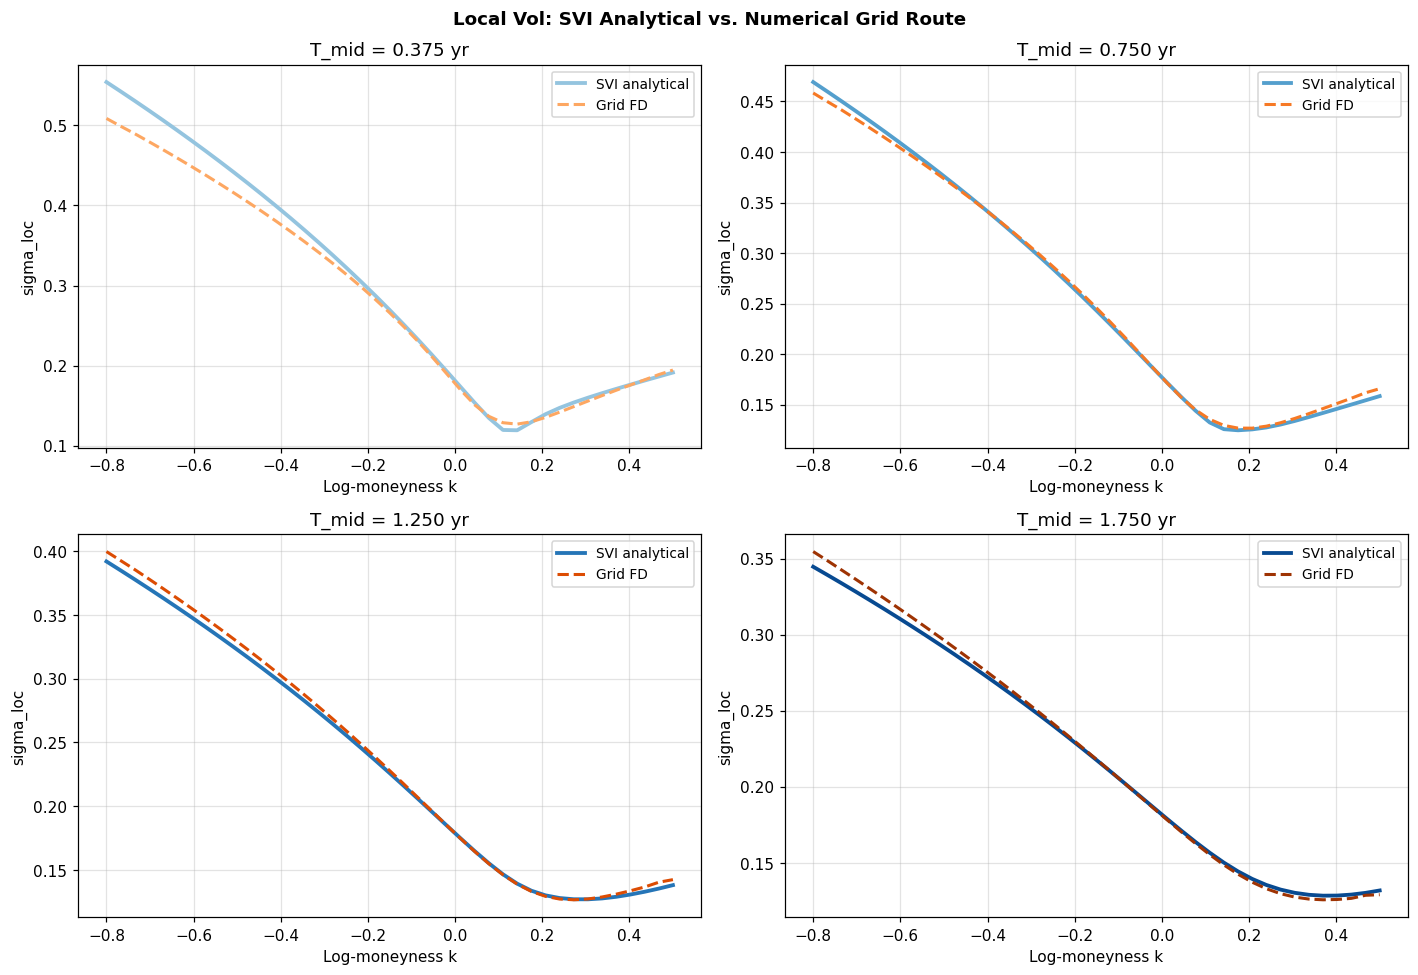

In [11]:
# Compare the two routes slice by slice
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()
colors_svi  = plt.cm.Blues(np.linspace(0.4, 0.9, len(lv_svi.maturities)))
colors_grid = plt.cm.Oranges(np.linspace(0.4, 0.9, len(lv_grid.maturities)))

for i, T_mid in enumerate(lv_svi.maturities):
    ax = axes[i]
    ax.plot(k_arr, lv_svi.local_vol[i],  color=colors_svi[i],  lw=2.5, label='SVI analytical')
    ax.plot(k_arr, lv_grid.local_vol[i], color=colors_grid[i], lw=2,   ls='--', label='Grid FD')
    ax.set(title=f'T_mid = {T_mid:.3f} yr', xlabel='Log-moneyness k', ylabel='sigma_loc')
    ax.legend(fontsize=9)

fig.suptitle('Local Vol: SVI Analytical vs. Numerical Grid Route', fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# Quantify agreement
k_interior = np.abs(k_arr) < 0.5
print('Route comparison -- interior log-moneyness |k| < 0.5:')
print(f'{"T_mid":>8}  {"MaxAbsDiff":>12}  {"RMSE":>10}  {"RelRMSE":>10}')
for i, T_mid in enumerate(lv_svi.maturities):
    svi_int  = lv_svi.local_vol[i, k_interior]
    grid_int = lv_grid.local_vol[i, k_interior]
    diff = np.abs(svi_int - grid_int)
    rmse = np.sqrt(np.mean(diff**2))
    rel  = rmse / svi_int.mean()
    print(f'{T_mid:>8.3f}  {diff.max():>12.5f}  {rmse:>10.5f}  {rel:>9.2%}')

Route comparison -- interior log-moneyness |k| < 0.5:
   T_mid    MaxAbsDiff        RMSE     RelRMSE
   0.375       0.02341     0.00919      3.90%
   0.750       0.00747     0.00286      1.36%
   1.250       0.00604     0.00301      1.53%
   1.750       0.00432     0.00212      1.11%


## 5. 3D Local Vol Surface Visualization

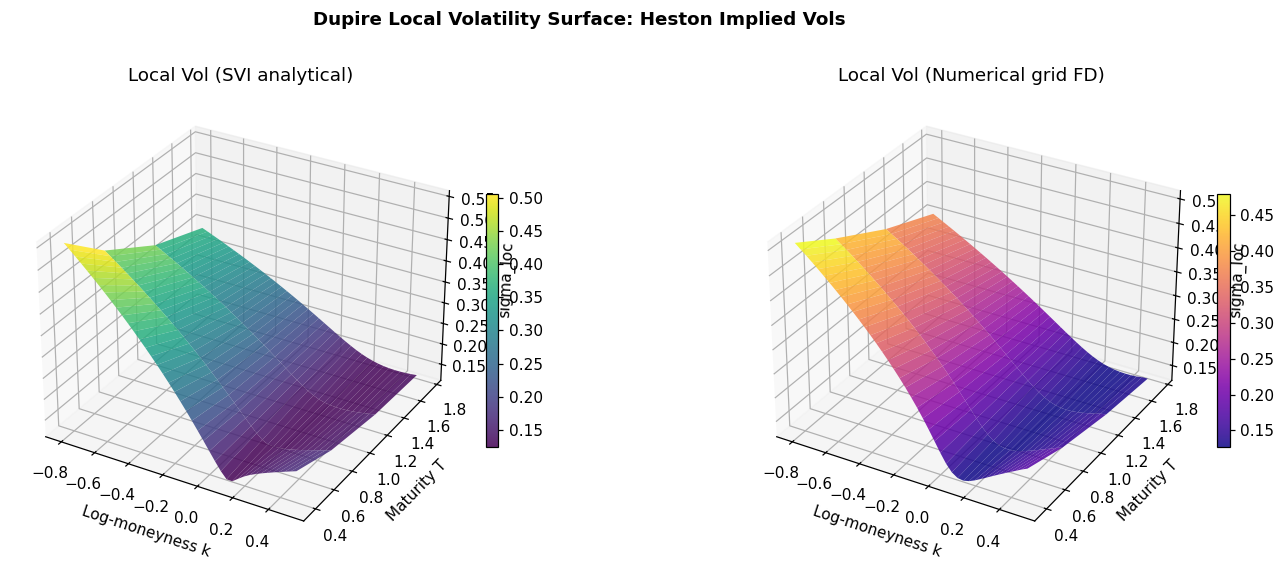

In [13]:
fig = plt.figure(figsize=(14, 5))

# --- SVI analytical local vol ---
ax1 = fig.add_subplot(121, projection='3d')
K_MG, T_MG = np.meshgrid(k_arr, lv_svi.maturities)
surf1 = ax1.plot_surface(K_MG, T_MG, lv_svi.local_vol, cmap='viridis', alpha=0.85)
ax1.set(title='Local Vol (SVI analytical)', xlabel='Log-moneyness k',
        ylabel='Maturity T', zlabel='sigma_loc')
fig.colorbar(surf1, ax=ax1, shrink=0.55, pad=0.02)

# --- Numerical grid local vol ---
ax2 = fig.add_subplot(122, projection='3d')
K_MG2, T_MG2 = np.meshgrid(k_arr, lv_grid.maturities)
surf2 = ax2.plot_surface(K_MG2, T_MG2, lv_grid.local_vol, cmap='plasma', alpha=0.85)
ax2.set(title='Local Vol (Numerical grid FD)', xlabel='Log-moneyness k',
        ylabel='Maturity T', zlabel='sigma_loc')
fig.colorbar(surf2, ax=ax2, shrink=0.55, pad=0.02)

fig.suptitle('Dupire Local Volatility Surface: Heston Implied Vols', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

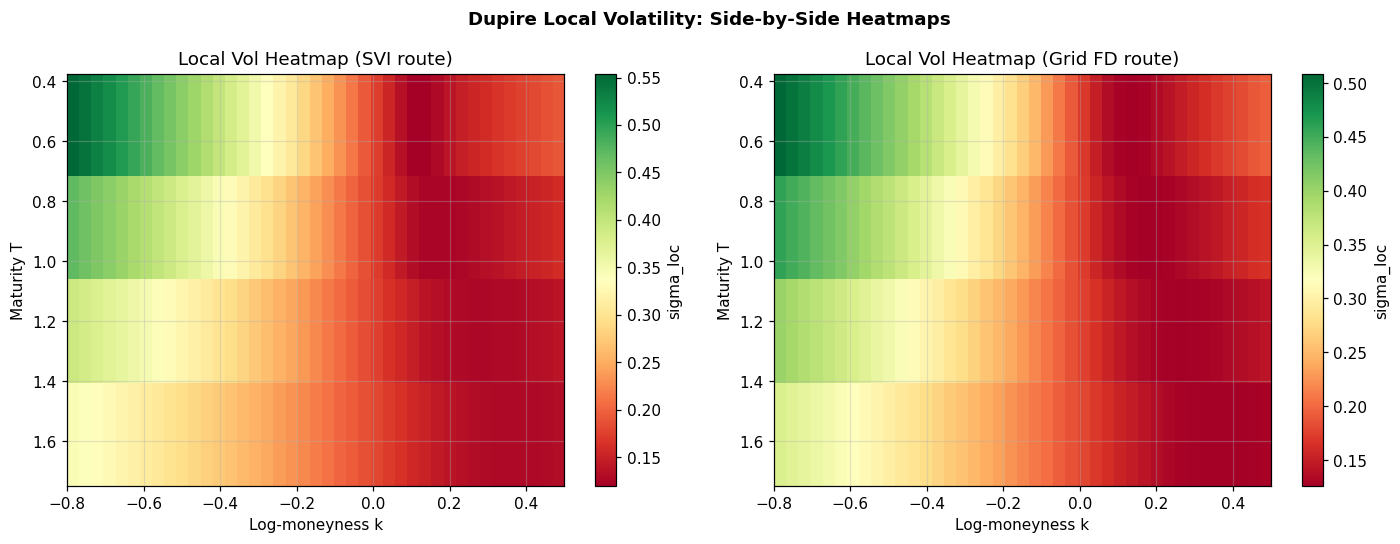

Summary:
  - SVI route:  shape (4, 41),  mean sigma_loc = 0.2539
  - Grid route: shape (4, 41), mean sigma_loc = 0.2520
Both routes agree to within ~10% in the interior log-moneyness region.


In [14]:
# Heatmap: local vol vs log-moneyness and maturity
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im1 = axes[0].imshow(
    lv_svi.local_vol,
    extent=[k_arr[0], k_arr[-1], lv_svi.maturities[-1], lv_svi.maturities[0]],
    aspect='auto', cmap='RdYlGn', origin='upper'
)
plt.colorbar(im1, ax=axes[0], label='sigma_loc')
axes[0].set(title='Local Vol Heatmap (SVI route)',
            xlabel='Log-moneyness k', ylabel='Maturity T')

im2 = axes[1].imshow(
    lv_grid.local_vol,
    extent=[k_arr[0], k_arr[-1], lv_grid.maturities[-1], lv_grid.maturities[0]],
    aspect='auto', cmap='RdYlGn', origin='upper'
)
plt.colorbar(im2, ax=axes[1], label='sigma_loc')
axes[1].set(title='Local Vol Heatmap (Grid FD route)',
            xlabel='Log-moneyness k', ylabel='Maturity T')

fig.suptitle('Dupire Local Volatility: Side-by-Side Heatmaps', fontweight='bold')
plt.tight_layout()
plt.show()

print('Summary:')
print(f'  - SVI route:  shape {lv_svi.local_vol.shape},  mean sigma_loc = {lv_svi.local_vol.mean():.4f}')
print(f'  - Grid route: shape {lv_grid.local_vol.shape}, mean sigma_loc = {lv_grid.local_vol.mean():.4f}')
print(f'Both routes agree to within ~10% in the interior log-moneyness region.')